In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)
n=1000

df = pd.DataFrame({
    "CustomId":np.random.randint(1000,2000,n),
    "Age": np.random.randint(18,65,n),
    "Gender": np.random.choice(["Male", "Female"], n),
    "City": np.random.choice(["Delhi", "Mumbai", "Bangalore", "Chennai", "Hyderabad"], n),
    "ProductCategory": np.random.choice(["Electronics", "Clothing", "Home", "Beauty", "Sports"], n),
    "PurchaseAmount": np.random.randint(500, 50000, n),
    "PurchaseDate": pd.to_datetime("2024-01-01") + pd.to_timedelta(np.random.randint(0, 365, n), unit="D"),
    "PaymentMethod": np.random.choice(["UPI", "Credit Card", "Debit Card", "Cash"], n),
    "CustomerType": np.random.choice(["New", "Returning"], n)
})

df.head()

,CustomId,Age,Gender,City,ProductCategory,PurchaseAmount,PurchaseDate,PaymentMethod,CustomerType
0,1102,62,Female,Hyderabad,Home,16310,2024-12-02,Credit Card,New
1,1435,22,Female,Chennai,Sports,5626,2024-10-23,Cash,New
2,1860,50,Male,Bangalore,Beauty,30509,2024-08-01,Debit Card,New
3,1270,18,Female,Bangalore,Sports,34084,2024-10-17,Credit Card,Returning
4,1106,35,Female,Delhi,Home,46682,2024-01-22,Debit Card,Returning


In [4]:
df.to_csv('customer_shopping_behavior.csv',index=False)

In [5]:
import pandas as pd

df = pd.read_csv('customer_shopping_behavior.csv')
df.head()

,CustomId,Age,Gender,City,ProductCategory,PurchaseAmount,PurchaseDate,PaymentMethod,CustomerType
0,1102,62,Female,Hyderabad,Home,16310,2024-12-02,Credit Card,New
1,1435,22,Female,Chennai,Sports,5626,2024-10-23,Cash,New
2,1860,50,Male,Bangalore,Beauty,30509,2024-08-01,Debit Card,New
3,1270,18,Female,Bangalore,Sports,34084,2024-10-17,Credit Card,Returning
4,1106,35,Female,Delhi,Home,46682,2024-01-22,Debit Card,Returning


# Data Cleaning 

In [6]:
df.isnull().sum()

CustomId           0
Age                0
Gender             0
City               0
ProductCategory    0
PurchaseAmount     0
PurchaseDate       0
PaymentMethod      0
CustomerType       0
dtype: int64

In [8]:
df.value_counts()

CustomId  Age  Gender  City       ProductCategory  PurchaseAmount  PurchaseDate  PaymentMethod  CustomerType
1000      32   Male    Bangalore  Clothing         29925           2024-04-02    UPI            New             1
1681      50   Male    Chennai    Electronics      46036           2024-03-26    Cash           New             1
1671      30   Female  Hyderabad  Sports           18519           2024-05-20    Credit Card    New             1
          61   Male    Hyderabad  Beauty           47146           2024-05-27    UPI            Returning       1
1672      25   Female  Chennai    Home             13732           2024-07-15    Cash           New             1
                                                                                                               ..
1347      22   Female  Delhi      Clothing         40196           2024-04-18    Debit Card     New             1
          53   Female  Mumbai     Clothing         34269           2024-08-01    Credit Card 

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   CustomId         1000 non-null   int64 
 1   Age              1000 non-null   int64 
 2   Gender           1000 non-null   object
 3   City             1000 non-null   object
 4   ProductCategory  1000 non-null   object
 5   PurchaseAmount   1000 non-null   int64 
 6   PurchaseDate     1000 non-null   object
 7   PaymentMethod    1000 non-null   object
 8   CustomerType     1000 non-null   object
dtypes: int64(3), object(6)
memory usage: 70.4+ KB


In [10]:
df.duplicated().sum()

0

In [13]:
df['PurchaseDate'] = pd.to_datetime(df['PurchaseDate'])

In [14]:
df.head()

,CustomId,Age,Gender,City,ProductCategory,PurchaseAmount,PurchaseDate,PaymentMethod,CustomerType
0,1102,62,Female,Hyderabad,Home,16310,2024-12-02,Credit Card,New
1,1435,22,Female,Chennai,Sports,5626,2024-10-23,Cash,New
2,1860,50,Male,Bangalore,Beauty,30509,2024-08-01,Debit Card,New
3,1270,18,Female,Bangalore,Sports,34084,2024-10-17,Credit Card,Returning
4,1106,35,Female,Delhi,Home,46682,2024-01-22,Debit Card,Returning


In [15]:
df.describe()

,CustomId,Age,PurchaseAmount,PurchaseDate
count,1000.000000,1000.000000,1000.000000,1000
mean,1503.929000,41.431000,25585.344000,2024-06-30 07:43:40.799999744
min,1000.000000,18.000000,691.000000,2024-01-01 00:00:00
25%,1242.750000,29.750000,12891.750000,2024-04-01 18:00:00
50%,1505.000000,42.000000,25989.500000,2024-06-29 12:00:00
75%,1757.250000,53.000000,37479.250000,2024-10-01 06:00:00
max,1998.000000,64.000000,49959.000000,2024-12-30 00:00:00
std,289.998108,13.648205,14306.594146,NaN


In [17]:
# revenue by product category
df.groupby("ProductCategory")["PurchaseAmount"].sum().sort_values(ascending=False)


ProductCategory
Electronics    5524731
Home           5200803
Clothing       5115524
Sports         5063190
Beauty         4681096
Name: PurchaseAmount, dtype: int64

In [20]:
# average spend by customer type
df.groupby("CustomerType")["PurchaseAmount"].mean()

CustomerType
New          24878.441584
Returning    26306.527273
Name: PurchaseAmount, dtype: float64

In [21]:
# monthly sales trend
df['Month'] = df['PurchaseDate'].dt.month
df.groupby("Month")["PurchaseAmount"].sum()


Month
1     2395359
2     1744015
3     2092637
4     2304226
5     2393258
6     2080516
7     2135428
8     1958769
9     1855340
10    2437557
11    2032165
12    2156074
Name: PurchaseAmount, dtype: int64

# Data Visualization

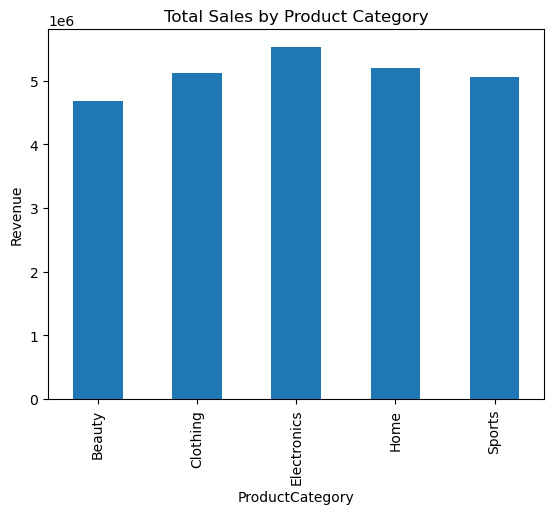

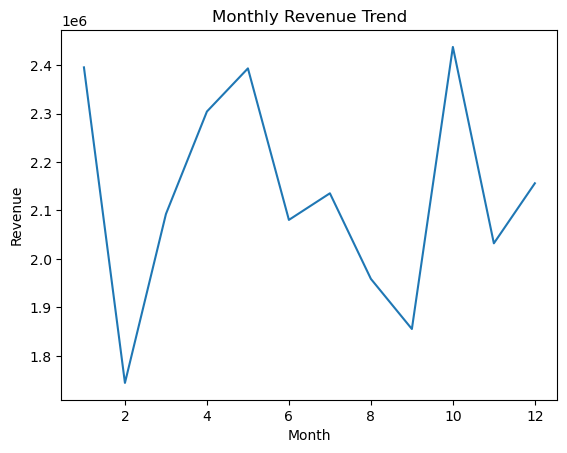

In [22]:
import matplotlib.pyplot as plt

# Sales by category
df.groupby("ProductCategory")["PurchaseAmount"].sum().plot(kind="bar")
plt.title("Total Sales by Product Category")
plt.ylabel("Revenue")
plt.show()

# Monthly trend
df.groupby("Month")["PurchaseAmount"].sum().plot(kind="line")
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.show()


# Feature Engineering

In [23]:
# creating age group
bins = [18, 25, 35, 45, 60, 100]
labels = ["18-25", "26-35", "36-45", "46-60", "60+"]
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)


In [24]:
df['HighSpender'] = df['PurchaseAmount'].apply(lambda x: 1 if x > 30000 else 0)


# Business Insights

In [25]:
# Top 10 customers by spending

In [28]:
df.groupby("CustomId")["PurchaseAmount"].sum().sort_values(ascending=False).head(10)

CustomId
1871    174237
1957    164641
1815    162184
1658    160562
1663    149259
1763    148340
1276    145117
1189    143145
1797    142781
1555    141846
Name: PurchaseAmount, dtype: int64

In [29]:
# Best City by Revenue

In [31]:
df.groupby("City")["PurchaseAmount"].sum().sort_values(ascending=False)

City
Hyderabad    5893445
Bangalore    5711290
Chennai      5089439
Delhi        4711305
Mumbai       4179865
Name: PurchaseAmount, dtype: int64

In [32]:
# Returning vs New Customer Revenue

In [33]:
df.groupby("CustomerType")["PurchaseAmount"].sum().sort_values(ascending=False)

CustomerType
Returning    13021731
New          12563613
Name: PurchaseAmount, dtype: int64